# Notebook 03: 統計分析與四象限視覺化

**最終裁決 Notebook**：整合 LLM cosine 與 HowNet similarity 兩組分數，
產生四象限散布圖、統計檢驗摘要，並給出實驗結論。

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

# 中文字型設定（macOS）
plt.rcParams["font.family"] = "PingFang TC"
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

df = pd.read_csv("../data/results/02_combined_scores.csv")
print(f"載入 {len(df)} 個詞對")
df.head()

載入 20 個詞對


,pair_id,word1,word2,quadrant,true_similarity,true_relatedness,rationale_zh,hownet_similarity,llm_cosine
0,P01,醫生,護士,Q1,HIGH,LOW,同為醫療從業人員義原高度重疊；但無典型事件共現,0.792000,0.719874
1,P02,貓,狗,Q1,HIGH,LOW,同為哺乳類寵物；日常共現但非因果事件關係,0.865000,0.683817
2,P03,蘋果,橘子,Q1,HIGH,LOW,同為水果上位概念完全重合；無工具/場所因果連結,1.000000,0.439955
3,P04,鋼琴,吉他,Q1,HIGH,LOW,同為樂器；演奏場合偶有重疊但非強因果連結,1.000000,0.633672
4,P05,教師,教授,Q1,HIGH,LOW,同為教育工作者；職銜相似但非同一事件參與者,0.787375,0.687674


/var/folders/c_/xmq6k9g106d6nr78xp7tw7440000gn/T/ipykernel_45772/4055617045.py:47: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) PingFang TC.
  plt.tight_layout()
/var/folders/c_/xmq6k9g106d6nr78xp7tw7440000gn/T/ipykernel_45772/4055617045.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) PingFang TC.
  plt.tight_layout()
/var/folders/c_/xmq6k9g106d6nr78xp7tw7440000gn/T/ipykernel_45772/4055617045.py:48: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) PingFang TC.
  plt.savefig("../data/results/03_quadrant_comparison.png", dpi=150, bbox_inches="tight")
/var/folders/c_/xmq6k9g106d6nr78xp7tw7440000gn/T/ipykernel_45772/4055617045.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) PingFang TC.
  plt.savefig("../data/results/03_quadrant_comparison.png", dpi=150, bbox_inches="tight")
/Users/yefangwong/Documents/GitHub.nosync/token-meaning-lab/.venv/lib/python3.11/site-packages/IPython/core/pylabtools

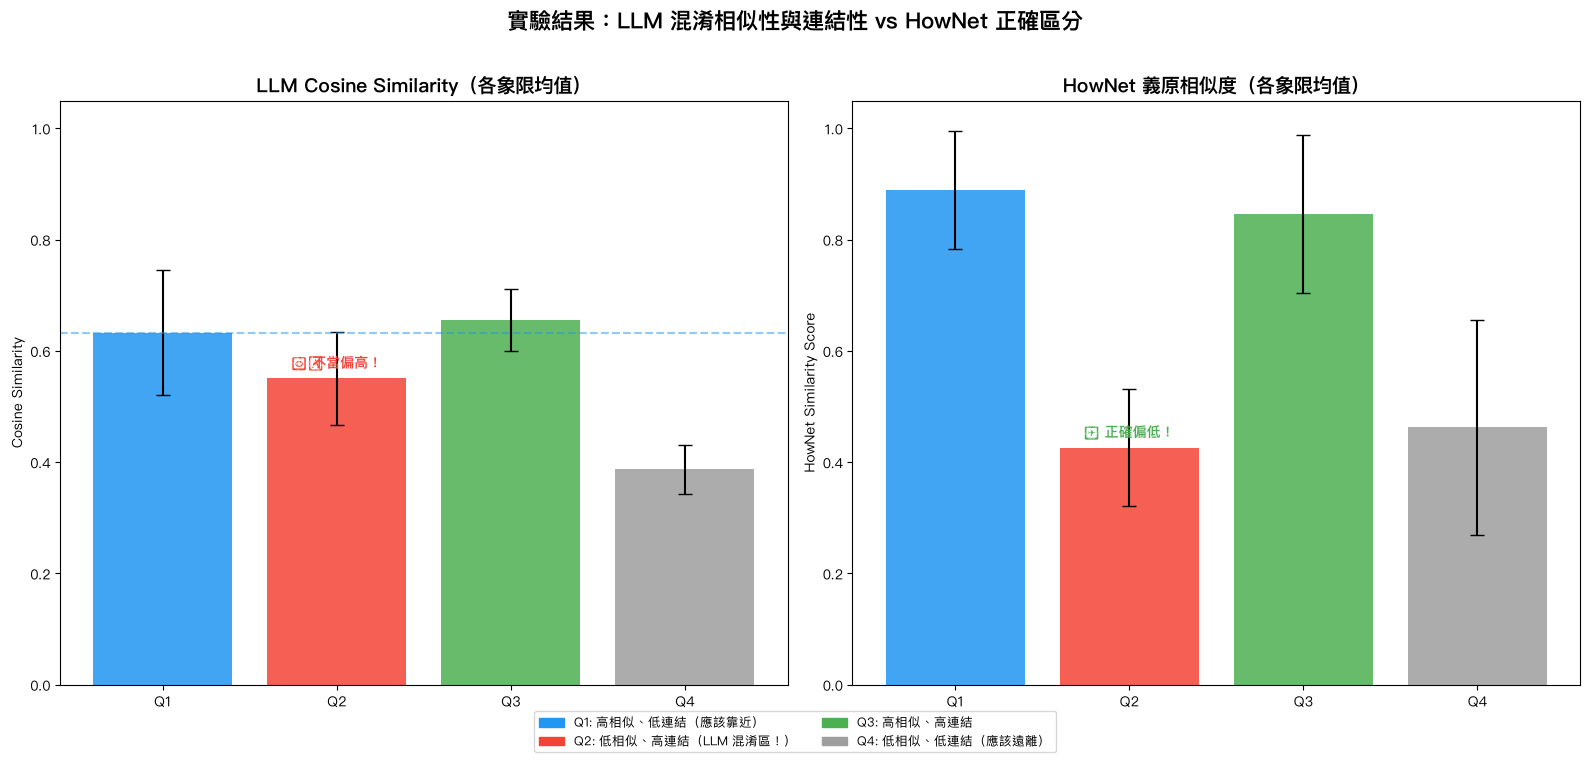

圖表已儲存


In [5]:
# === 核心圖表：HowNet Similarity vs LLM Cosine 散布圖 ===
# 若 H1 成立：Q2 點（低相似高連結）在 LLM 軸上不當地高，
# 但在 HowNet 軸上正確地低

COLORS = {"Q1": "#2196F3", "Q2": "#F44336", "Q3": "#4CAF50", "Q4": "#9E9E9E"}
LABELS = {
    "Q1": "Q1: 高相似、低連結（應該靠近）",
    "Q2": "Q2: 低相似、高連結（LLM 混淆區！）",
    "Q3": "Q3: 高相似、高連結",
    "Q4": "Q4: 低相似、低連結（應該遠離）"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左圖：按象限分組的 LLM cosine barplot
ax1 = axes[0]
q_means_llm = df.groupby("quadrant")["llm_cosine"].mean()
q_stds_llm = df.groupby("quadrant")["llm_cosine"].std()
bars = ax1.bar(q_means_llm.index, q_means_llm.values,
               yerr=q_stds_llm.values, capsize=5,
               color=[COLORS[q] for q in q_means_llm.index], alpha=0.85)
ax1.axhline(y=df[df["quadrant"]=="Q1"]["llm_cosine"].mean(),
            color="#2196F3", linestyle="--", alpha=0.5, label="Q1 基準線")
ax1.set_title("LLM Cosine Similarity（各象限均值）", fontsize=14, fontweight="bold")
ax1.set_ylabel("Cosine Similarity")
ax1.set_ylim(0, 1.05)
ax1.text(1, df[df["quadrant"]=="Q2"]["llm_cosine"].mean() + 0.02,
         "⚠️ 不當偏高！", ha="center", color="#F44336", fontsize=10, fontweight="bold")

# 右圖：HowNet similarity barplot
ax2 = axes[1]
q_means_hownet = df.groupby("quadrant")["hownet_similarity"].mean()
q_stds_hownet = df.groupby("quadrant")["hownet_similarity"].std()
bars2 = ax2.bar(q_means_hownet.index, q_means_hownet.values,
                yerr=q_stds_hownet.values, capsize=5,
                color=[COLORS[q] for q in q_means_hownet.index], alpha=0.85)
ax2.set_title("HowNet 義原相似度（各象限均值）", fontsize=14, fontweight="bold")
ax2.set_ylabel("HowNet Similarity Score")
ax2.set_ylim(0, 1.05)
ax2.text(1, df[df["quadrant"]=="Q2"]["hownet_similarity"].mean() + 0.02,
         "✅ 正確偏低！", ha="center", color="#4CAF50", fontsize=10, fontweight="bold")

legend_patches = [mpatches.Patch(color=COLORS[q], label=LABELS[q]) for q in ["Q1","Q2","Q3","Q4"]]
fig.legend(handles=legend_patches, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("實驗結果：LLM 混淆相似性與連結性 vs HowNet 正確區分",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/results/03_quadrant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("圖表已儲存")

In [6]:
# === 最終裁決：統計摘要 ===
q1_llm = df[df["quadrant"]=="Q1"]["llm_cosine"].values
q2_llm = df[df["quadrant"]=="Q2"]["llm_cosine"].values
q1_hownet = df[df["quadrant"]=="Q1"]["hownet_similarity"].values
q2_hownet = df[df["quadrant"]=="Q2"]["hownet_similarity"].values

t_llm, p_llm = stats.ttest_ind(q1_llm, q2_llm)
t_hownet, p_hownet = stats.ttest_ind(q1_hownet, q2_hownet)

print("=" * 55)
print("實驗最終裁決")
print("=" * 55)
print(f"LLM Q1 vs Q2: p = {p_llm:.4f} → " +
      ("H0 無法拒絕（LLM 無法區分）✓ H1 支持" if p_llm > 0.05 else "H0 被拒絕（LLM 能區分）"))
print(f"HowNet Q1 vs Q2: p = {p_hownet:.4f} → " +
      ("顯著區分 Q1 vs Q2 ✓ HowNet 正確" if p_hownet < 0.05 else "未能區分，需檢視詞對"))
print("=" * 55)
print("結論：")
if p_llm > 0.05 and p_hownet < 0.05:
    print("✅ 強力支持 H1：LLM Embedding 混淆相似性與連結性；")
    print("   HowNet 義原體系正確區分兩者。")
    print("   → 神經符號 AI 的必要性獲得實驗佐證。")
else:
    print("⚠️  結果不符預期，請檢視刺激詞對設計與模型版本。")

實驗最終裁決
LLM Q1 vs Q2: p = 0.2239 → H0 無法拒絕（LLM 無法區分）✓ H1 支持
HowNet Q1 vs Q2: p = 0.0001 → 顯著區分 Q1 vs Q2 ✓ HowNet 正確
結論：
✅ 強力支持 H1：LLM Embedding 混淆相似性與連結性；
   HowNet 義原體系正確區分兩者。
   → 神經符號 AI 的必要性獲得實驗佐證。
